In [168]:
import pandas as pd
import numpy as np

In [169]:
df = pd.read_csv("../data/processed/deploypilot_ai_ci_cd_pipeline_dataset.csv")

In [170]:
print("Dataset shape:", df.shape)

Dataset shape: (20000, 31)


In [171]:
df['cloud_provider'] = df['cloud_provider'].fillna('Unknown')

In [172]:
print("Missing values in dataset:", df.isnull().sum().sum())
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values in dataset: 40000
failure_stage    10000
failure_type     10000
error_code       10000
severity         10000
dtype: int64


In [173]:
label = df['result']

feature_columns = [
    'commit_size',
    'files_changed',
    'warnings',
    'tests_failed',
    'previous_failure_rate',
    'build_duration_sec',
    'test_duration_sec',
    'deploy_duration_sec',
    'cpu_usage_pct',
    'memory_usage_mb',
    'retry_count',
    'ci_tool',
    'branch',
    'language',
    'os',
    'cloud_provider'
]

features = df[feature_columns]

In [174]:
print(features.columns)

Index(['commit_size', 'files_changed', 'warnings', 'tests_failed',
       'previous_failure_rate', 'build_duration_sec', 'test_duration_sec',
       'deploy_duration_sec', 'cpu_usage_pct', 'memory_usage_mb',
       'retry_count', 'ci_tool', 'branch', 'language', 'os', 'cloud_provider'],
      dtype='str')


In [175]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    features,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

In [176]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (16000, 16)
x_test shape: (4000, 16)
y_train shape: (16000,)
y_test shape: (4000,)


In [177]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
result
PASS    0.5
FAIL    0.5
Name: proportion, dtype: float64

Testing class distribution:
result
PASS    0.5
FAIL    0.5
Name: proportion, dtype: float64


In [178]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [179]:
numerical_features = [
    'commit_size',
    'files_changed',
    'warnings',
    'tests_failed',
    'previous_failure_rate',
    'build_duration_sec',
    'test_duration_sec',
    'deploy_duration_sec',
    'cpu_usage_pct',
    'memory_usage_mb',
    'retry_count'
]

categorical_features = [
    'ci_tool',
    'branch',
    'language',
    'os',
    'cloud_provider'
]

In [180]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            SimpleImputer(strategy='median'),
            numerical_features
        ),
        (
            'categorical',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        )
    ]
)

In [181]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    probabilities = model.predict_proba(x_test)
    fail_index = list(model.classes_).index('FAIL')
    y_probability = probabilities[:, fail_index]
    y_test_binary = (y_test == 'FAIL').astype(int)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1-score:", f1_score(y_test, y_pred, average="weighted"))
    print("ROC-AUC:", roc_auc_score(y_test_binary, y_probability))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred, labels=['PASS','FAIL']))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [182]:
from sklearn.ensemble import RandomForestClassifier

In [183]:
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=50,
        max_depth=2,
        min_samples_leaf=30,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

model_rf.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['FAIL','PASS']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['commit_size','files_changed','warnings',...,'language','os', 'cloud_provider']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [184]:
evaluate_model(model_rf, x_test, y_test)

Accuracy: 0.86225
Precision: 0.8622899424661569
Recall: 0.86225
F1-score: 0.8622462031609746
ROC-AUC: 0.9131907499999999

Confusion Matrix:
[[1714  286]
 [ 265 1735]]

Classification Report:
              precision    recall  f1-score   support

        FAIL       0.86      0.87      0.86      2000
        PASS       0.87      0.86      0.86      2000

    accuracy                           0.86      4000
   macro avg       0.86      0.86      0.86      4000
weighted avg       0.86      0.86      0.86      4000



In [185]:
model_rf_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

model_rf_v2.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['FAIL','PASS']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['commit_size','files_changed','warnings',...,'language','os', 'cloud_provider']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [186]:
evaluate_model(model_rf_v2, x_test, y_test)

Accuracy: 0.9015
Precision: 0.9020504070071929
Recall: 0.9015
F1-score: 0.9014662768332462
ROC-AUC: 0.98124275

Confusion Matrix:
[[1840  160]
 [ 234 1766]]

Classification Report:
              precision    recall  f1-score   support

        FAIL       0.92      0.88      0.90      2000
        PASS       0.89      0.92      0.90      2000

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000



In [187]:
model_rf_v3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

model_rf_v3.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['FAIL','PASS']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['commit_size','files_changed','warnings',...,'language','os', 'cloud_provider']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [188]:
evaluate_model(model_rf_v3, x_test, y_test)

Accuracy: 0.9265
Precision: 0.9295307691068178
Recall: 0.9265
F1-score: 0.9263701168861872
ROC-AUC: 0.9822775000000001

Confusion Matrix:
[[1937   63]
 [ 231 1769]]

Classification Report:
              precision    recall  f1-score   support

        FAIL       0.97      0.88      0.92      2000
        PASS       0.89      0.97      0.93      2000

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



In [189]:
model_rf_v4 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=9,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

model_rf_v4.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['FAIL','PASS']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['commit_size','files_changed','warnings',...,'language','os', 'cloud_provider']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [190]:
evaluate_model(model_rf_v4, x_test, y_test)

Accuracy: 0.936
Precision: 0.9409545654979348
Recall: 0.936
F1-score: 0.935819717586701
ROC-AUC: 0.9851805

Confusion Matrix:
[[1978   22]
 [ 234 1766]]

Classification Report:
              precision    recall  f1-score   support

        FAIL       0.99      0.88      0.93      2000
        PASS       0.89      0.99      0.94      2000

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000



In [191]:
# %pip install xgboost

In [192]:
from xgboost import XGBClassifier

In [193]:
y_train_xgb = y_train.map({'PASS': 0, 'FAIL': 1})
y_test_xgb = y_test.map({'PASS': 0, 'FAIL': 1})

In [194]:
def evaluate_xgboost_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    y_probability = model.predict_proba(x_test)[:, 1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1-score:", f1_score(y_test, y_pred, average="weighted"))
    print("ROC-AUC:", roc_auc_score(y_test, y_probability))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [195]:
model_xgboost = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=50,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

model_xgboost.fit(x_train, y_train_xgb)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['commit_size','files_changed','warnings',...,'language','os', 'cloud_provider']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [196]:
evaluate_xgboost_model(model_xgboost, x_test, y_test_xgb)

Accuracy: 0.8635
Precision: 0.8635032715294437
Recall: 0.8635
F1-score: 0.8634996928743089
ROC-AUC: 0.91807825

Confusion Matrix:
[[1730  270]
 [ 276 1724]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      2000
           1       0.86      0.86      0.86      2000

    accuracy                           0.86      4000
   macro avg       0.86      0.86      0.86      4000
weighted avg       0.86      0.86      0.86      4000



In [197]:
model_xgboost_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=80,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

model_xgboost_v2.fit(x_train, y_train_xgb)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['commit_size','files_changed','warnings',...,'language','os', 'cloud_provider']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [198]:
evaluate_xgboost_model(model_xgboost_v2, x_test, y_test_xgb)

Accuracy: 0.87025
Precision: 0.8711229740156283
Recall: 0.87025
F1-score: 0.8701736539944022
ROC-AUC: 0.960523875

Confusion Matrix:
[[1789  211]
 [ 308 1692]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      2000
           1       0.89      0.85      0.87      2000

    accuracy                           0.87      4000
   macro avg       0.87      0.87      0.87      4000
weighted avg       0.87      0.87      0.87      4000



In [199]:
random_forest_names = [
    'Random Forest Baseline',
    'Random Forest v2',
    'Random Forest v3',
    'Random Forest v4'
]

random_forest_models = [
    model_rf,
    model_rf_v2,
    model_rf_v3,
    model_rf_v4
]

xgboost_names = [
    'XGBoost Baseline',
    'XGBoost v2'
]

xgboost_models = [
    model_xgboost,
    model_xgboost_v2,
]

In [200]:
model_results = []

for model_name, current_model in zip(
    random_forest_names,
    random_forest_models
):
    predictions = current_model.predict(x_test)
    probabilities = current_model.predict_proba(x_test)
    fail_index = list(current_model.classes_).index('FAIL')
    fail_probabilities = probabilities[:, fail_index]
    y_test_binary = (y_test == 'FAIL').astype(int)

    model_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, average='weighted'),
        'Recall': recall_score(y_test, predictions, average='weighted'),
        'F1-score': f1_score(y_test, predictions, average='weighted'),
        'ROC-AUC': roc_auc_score(y_test_binary, fail_probabilities)
    })

for model_name, current_model in zip(
    xgboost_names,
    xgboost_models
):
    predictions = current_model.predict(x_test)
    probabilities = current_model.predict_proba(x_test)[:, 1]

    model_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_xgb, predictions),
        'Precision': precision_score(y_test_xgb, predictions, average='weighted'),
        'Recall': recall_score(y_test_xgb, predictions, average='weighted'),
        'F1-score': f1_score(y_test_xgb, predictions, average='weighted'),
        'ROC-AUC': roc_auc_score(y_test_xgb, probabilities)
    })

In [201]:
model_comparison = pd.DataFrame(model_results)

model_comparison = model_comparison.sort_values(
    by='F1-score',
    ascending=False
)

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Random Forest v4,0.93600,0.940955,0.93600,0.935820,0.985181
2,Random Forest v3,0.92650,0.929531,0.92650,0.926370,0.982278
1,Random Forest v2,0.90150,0.902050,0.90150,0.901466,0.981243
5,XGBoost v2,0.87025,0.871123,0.87025,0.870174,0.960524
4,XGBoost Baseline,0.86350,0.863503,0.86350,0.863500,0.918078
0,Random Forest Baseline,0.86225,0.862290,0.86225,0.862246,0.913191


In [202]:
best_model_name = model_comparison.iloc[0]['Model']

print("Best model:", best_model_name)

if best_model_name == 'Random Forest v4':
    best_model = model_rf_v4
else:
    best_model = model_rf_v3

Best model: Random Forest v4


In [203]:
evaluate_model(best_model, x_test, y_test)

Accuracy: 0.936
Precision: 0.9409545654979348
Recall: 0.936
F1-score: 0.935819717586701
ROC-AUC: 0.9851805

Confusion Matrix:
[[1978   22]
 [ 234 1766]]

Classification Report:
              precision    recall  f1-score   support

        FAIL       0.99      0.88      0.93      2000
        PASS       0.89      0.99      0.94      2000

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000



In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

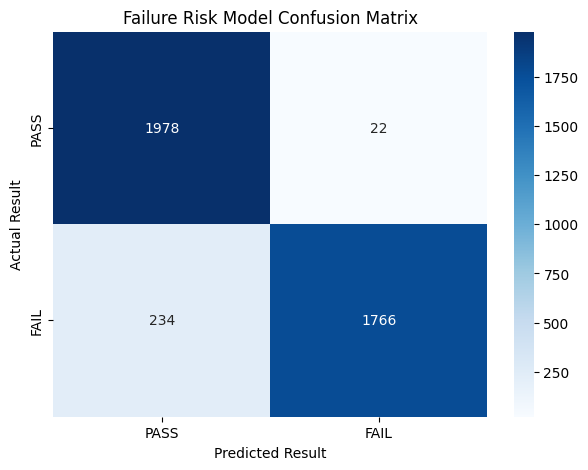

In [205]:
final_predictions = best_model.predict(x_test)

cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=['PASS','FAIL']
)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['PASS','FAIL'],
    yticklabels=['PASS','FAIL']
)
plt.title('Failure Risk Model Confusion Matrix')
plt.xlabel('Predicted Result')
plt.ylabel('Actual Result')
plt.show()

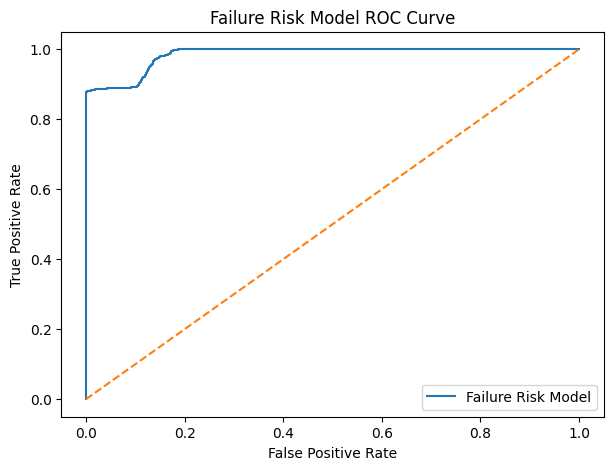

In [206]:
from sklearn.metrics import roc_curve

final_probabilities = best_model.predict_proba(x_test)
fail_index = list(best_model.classes_).index('FAIL')
final_fail_probability = final_probabilities[:, fail_index]
y_test_binary = (y_test == 'FAIL').astype(int)

fpr, tpr, thresholds = roc_curve(
    y_test_binary,
    final_fail_probability
)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label='Failure Risk Model')
plt.plot([0,1], [0,1], linestyle='--')
plt.title('Failure Risk Model ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [207]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feature_importance = best_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

importance_df

,Feature,Importance
4,numeric__previous_failure_rate,0.196955
9,numeric__memory_usage_mb,0.174759
2,numeric__warnings,0.095521
10,numeric__retry_count,0.093653
7,numeric__deploy_duration_sec,0.084507
5,numeric__build_duration_sec,0.073824
1,numeric__files_changed,0.073215
6,numeric__test_duration_sec,0.072005
0,numeric__commit_size,0.055072
8,numeric__cpu_usage_pct,0.048445


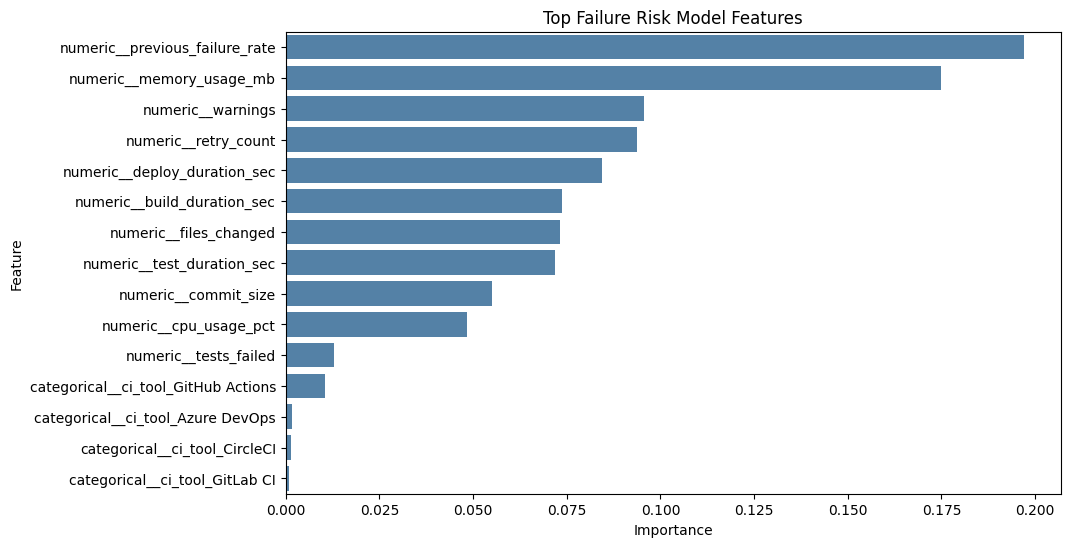

In [208]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    color='steelblue'
)

plt.title('Top Failure Risk Model Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
import joblib
import json
import os

In [ ]:
os.makedirs('../models', exist_ok=True)

joblib.dump(
     best_model,
     '../models/failure_risk_model.pkl'
 )

print("Failure risk model saved successfully.")

In [ ]:
final_predictions = best_model.predict(x_test)
final_probabilities = best_model.predict_proba(x_test)
fail_index = list(best_model.classes_).index('FAIL')
final_fail_probability = final_probabilities[:, fail_index]
y_test_binary = (y_test == 'FAIL').astype(int)

risk_metrics = {
    'model_name': best_model_name,
    'accuracy': float(accuracy_score(y_test, final_predictions)),
    'precision': float(precision_score(y_test, final_predictions, average='weighted')),
    'recall': float(recall_score(y_test, final_predictions, average='weighted')),
    'f1_score': float(f1_score(y_test, final_predictions, average='weighted')),
    'roc_auc': float(roc_auc_score(y_test_binary, final_fail_probability))
}

with open('../models/failure_risk_metrics.json', 'w') as file:
    json.dump(risk_metrics, file, indent=4)

risk_metrics

In [ ]:
loaded_model = joblib.load(
    '../models/failure_risk_model.pkl'
)

print("Final model loaded successfully.")
print("Model type:", type(loaded_model))
print("Model classes:", loaded_model.classes_)

In [ ]:
sample = x_test.iloc[[0]]

print("Actual result:", y_test.iloc[0])
print("Predicted result:", loaded_model.predict(sample)[0])

sample_probabilities = loaded_model.predict_proba(sample)[0]
fail_index = list(loaded_model.classes_).index('FAIL')
print("Failure probability:", sample_probabilities[fail_index])

In [ ]:
high_risk_examples = x_test.copy()

fail_index = list(
    best_model.classes_
).index("FAIL")

high_risk_examples["risk_score"] = (
    best_model.predict_proba(x_test)[:, fail_index]
)

high_risk_examples["actual_result"] = (
    y_test.values
)

high_risk_examples["prediction"] = (
    best_model.predict(x_test)
)

high_risk_examples = (
    high_risk_examples
    .sort_values(
        by="risk_score",
        ascending=False
    )
)

high_risk_examples.head()